#### Import required python packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

## Create the data

#### Import tables

In [2]:
transactions = pd.read_excel("data/grocery_database.xlsx", sheet_name = "transactions")
product_areas = pd.read_excel("data/grocery_database.xlsx", sheet_name = "product_areas")

#### Merge on product area name

In [4]:
transactions = pd.merge(transactions, product_areas, how = "inner", on = "product_area_id")

#### Drop the non-food category

In [5]:
transactions.drop(transactions[transactions["product_area_name"] == "Non-Food"].index, inplace = True)

#### Aggregate sales at customer level (by product area)

In [6]:
transaction_summary = transactions.groupby(["customer_id", "product_area_name"])["sales_cost"].sum().reset_index()
print(transaction_summary)

      customer_id product_area_name  sales_cost
0               1             Dairy      367.74
1               1             Fruit      276.00
2               1              Meat      543.38
3               1        Vegetables      167.12
4               2             Dairy      150.63
...           ...               ...         ...
3151          869        Vegetables      168.85
3152          870             Dairy      247.97
3153          870             Fruit      322.90
3154          870              Meat      284.26
3155          870        Vegetables      203.80

[3156 rows x 3 columns]


#### Pivot data to place product areas as columns

In [7]:
transaction_summary_pivot = transactions.pivot_table(index = "customer_id",
                                                    columns = "product_area_name",
                                                    values = "sales_cost",
                                                    aggfunc = "sum",
                                                    fill_value = 0,
                                                    margins = True,
                                                    margins_name = "Total").rename_axis(None,axis = 1)

print(transaction_summary_pivot)                                                          

                 Dairy      Fruit       Meat  Vegetables      Total
customer_id                                                        
1               367.74     276.00     543.38      167.12    1354.24
2               150.63     120.93     241.21       99.05     611.82
3                46.20      75.39     171.13       31.50     324.22
4               341.91     245.36     272.79      142.35    1002.41
5               694.71     815.32    1405.19      350.10    3265.32
...                ...        ...        ...         ...        ...
867             129.84     176.73     180.49       88.83     575.89
868             225.59     358.89     343.26      189.24    1116.98
869             126.28     127.50     183.88      168.85     606.51
870             247.97     322.90     284.26      203.80    1058.93
Total        175792.77  252033.53  240892.82   133879.25  802598.37

[871 rows x 5 columns]


#### Turn sales into % sales

In [9]:
transaction_summary_pivot = transaction_summary_pivot.div(transaction_summary_pivot["Total"], axis = 0)
print(transaction_summary_pivot)

                Dairy     Fruit      Meat  Vegetables  Total
customer_id                                                 
1            0.271547  0.203804  0.401244    0.123405    1.0
2            0.246200  0.197656  0.394250    0.161894    1.0
3            0.142496  0.232527  0.527821    0.097156    1.0
4            0.341088  0.244770  0.272134    0.142008    1.0
5            0.212754  0.249691  0.430338    0.107218    1.0
...               ...       ...       ...         ...    ...
867          0.225460  0.306882  0.313411    0.154248    1.0
868          0.201964  0.321304  0.307311    0.169421    1.0
869          0.208208  0.210219  0.303177    0.278396    1.0
870          0.234170  0.304930  0.268441    0.192458    1.0
Total        0.219030  0.314022  0.300141    0.166807    1.0

[871 rows x 5 columns]


#### Drop the "total" column

In [11]:
data_for_clustering = transaction_summary_pivot.drop(["Total"], axis = 1)
print(data_for_clustering)

                Dairy     Fruit      Meat  Vegetables
customer_id                                          
1            0.271547  0.203804  0.401244    0.123405
2            0.246200  0.197656  0.394250    0.161894
3            0.142496  0.232527  0.527821    0.097156
4            0.341088  0.244770  0.272134    0.142008
5            0.212754  0.249691  0.430338    0.107218
...               ...       ...       ...         ...
867          0.225460  0.306882  0.313411    0.154248
868          0.201964  0.321304  0.307311    0.169421
869          0.208208  0.210219  0.303177    0.278396
870          0.234170  0.304930  0.268441    0.192458
Total        0.219030  0.314022  0.300141    0.166807

[871 rows x 4 columns]


## Data preparation and cleaning

#### Check for missing values

In [12]:
data_for_clustering.isna().sum()

Dairy         0
Fruit         0
Meat          0
Vegetables    0
dtype: int64

#### Normalise data

In [13]:
scale_norm = MinMaxScaler()
data_for_clustering_scaled = pd.DataFrame(scale_norm.fit_transform(data_for_clustering), columns = data_for_clustering.columns)
print(data_for_clustering_scaled)

        Dairy     Fruit      Meat  Vegetables
0    0.309044  0.250873  0.432358    0.164665
1    0.280196  0.243305  0.424823    0.216022
2    0.162172  0.286229  0.568751    0.129640
3    0.388187  0.301300  0.293237    0.189487
4    0.242132  0.307357  0.463709    0.143065
..        ...       ...       ...         ...
866  0.256592  0.377756  0.337714    0.205820
867  0.229852  0.395509  0.331142    0.226066
868  0.236958  0.258769  0.326687    0.371476
869  0.266506  0.375354  0.289257    0.256806
870  0.249274  0.386545  0.323416    0.222578

[871 rows x 4 columns]


## Use WCSS to find a good value for k

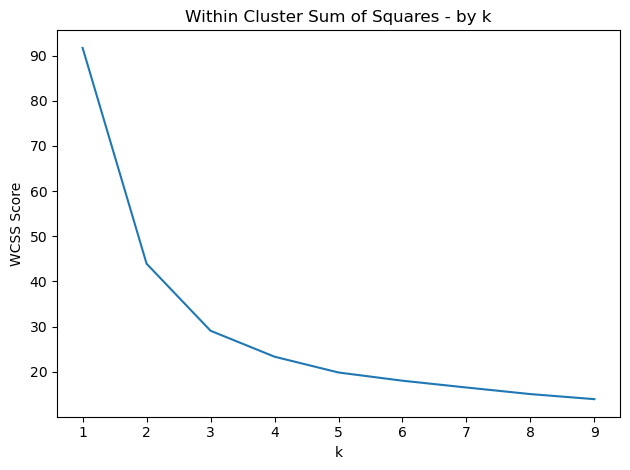

In [26]:
k_values = list(range(1,10))
wcss_list = []

for k in k_values:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(data_for_clustering_scaled)
    wcss_list.append(kmeans.inertia_)

plt.plot(k_values, wcss_list)
plt.title("Within Cluster Sum of Squares - by k")
plt.xlabel("k")
plt.ylabel("WCSS Score")
plt.tight_layout()
plt.show()

## Instantiate and fit model

In [27]:
kmeans = KMeans(n_clusters = 3, random_state = 42, n_init = 10)
kmeans.fit(data_for_clustering_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


## Use cluster information

#### Add cluster labels to our data

In [28]:
data_for_clustering["cluster"] = kmeans.labels_

#### Check cluster sizes

In [29]:
data_for_clustering["cluster"].value_counts()

cluster
1    641
0    127
2    103
Name: count, dtype: int64

## Profile our clusters

In [30]:
cluster_summary = data_for_clustering.groupby("cluster")[["Dairy", "Fruit", "Meat", "Vegetables"]].mean().reset_index()
print(cluster_summary)

   cluster     Dairy     Fruit      Meat  Vegetables
0        0  0.363948  0.394152  0.029210    0.212690
1        1  0.220875  0.264605  0.376508    0.138011
2        2  0.002382  0.637796  0.003696    0.356126
